# Python Conversion Scaffold of the Suicide Rates Project

This notebook was generated from the uploaded R Markdown file.

It is divided into:

## PART 1 — Yilmaz
Data Cleaning & Preprocessing

## PART 2 — Lukasz
EDA & Visualization

## PART 3 — Mustafa
Statistical Modeling & Machine Learning

The original R notebook content is preserved below so it can be converted section-by-section into Python.


In [2]:
# ==========================================
# PART 1 - DATA CLEANING & PREPROCESSING
# ==========================================

import pandas as pd
import numpy as np
import pycountry_convert as pc

# ------------------------------------------
# LOAD DATA
# ------------------------------------------

df = pd.read_csv("data/master.csv")

print(df.shape)
print(df.head())


# ------------------------------------------
# REMOVE UNUSED COLUMNS
# ------------------------------------------

df = df.drop(
    columns=[
        "HDI for year",
        "suicides/100k pop"
    ]
)

# ------------------------------------------
# RENAME COLUMNS
# ------------------------------------------

df = df.rename(
    columns={
        "gdp_for_year ($)": "gdp_for_year",
        "gdp_per_capita ($)": "gdp_per_capita",
        "country-year": "country_year"
    }
)

# ------------------------------------------
# REMOVE 2016
# ------------------------------------------

df = df[df["year"] != 2016]

# ------------------------------------------
# REMOVE COUNTRIES WITH <=3 YEARS DATA
# ------------------------------------------

country_years = (
    df.groupby("country")
      .size()
      .reset_index(name="rows")
)

country_years["years"] = country_years["rows"] / 12

countries_to_remove = (
    country_years
    .sort_values("years")
    .head(7)["country"]
    .tolist()
)

df = df[
    ~df["country"].isin(countries_to_remove)
]

# ------------------------------------------
# CLEAN AGE COLUMN
# ------------------------------------------

df["age"] = (
    df["age"]
    .str.replace(" years", "", regex=False)
)

# ------------------------------------------
# CLEAN SEX COLUMN
# ------------------------------------------

df["sex"] = df["sex"].replace(
    {
        "male": "Male",
        "female": "Female"
    }
)

# ------------------------------------------
# ADD CONTINENT
# ------------------------------------------

def country_to_continent(country_name):

    try:

        country_alpha2 = pc.country_name_to_country_alpha2(
            country_name
        )

        continent_code = pc.country_alpha2_to_continent_code(
            country_alpha2
        )

        continent_names = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
        }

        return continent_names.get(continent_code)

    except:
        return np.nan


df["continent"] = (
    df["country"]
    .apply(country_to_continent)
)

# ------------------------------------------
# ORDER AGE VARIABLE
# ------------------------------------------

age_order = [
    "5-14",
    "15-24",
    "25-34",
    "35-54",
    "55-74",
    "75+"
]

df["age"] = pd.Categorical(
    df["age"],
    categories=age_order,
    ordered=True
)

# ------------------------------------------
# ORDER GENERATION VARIABLE
# ------------------------------------------

generation_order = [
    "G.I. Generation",
    "Silent",
    "Boomers",
    "Generation X",
    "Millenials",
    "Generation Z"
]

df["generation"] = pd.Categorical(
    df["generation"],
    categories=generation_order,
    ordered=True
)

# ------------------------------------------
# CONVERT TO CATEGORICAL
# ------------------------------------------

for col in [
    "country",
    "sex",
    "continent"
]:
    df[col] = df[col].astype("category")

# ------------------------------------------
# GLOBAL AVERAGE SUICIDE RATE
# ------------------------------------------

global_average = (
    df["suicides_no"].sum()
    /
    df["population"].sum()
) * 100000

print(
    f"Global Average Suicide Rate: "
    f"{global_average:.2f}"
)

# ------------------------------------------
# DATA VALIDATION
# ------------------------------------------

print("\nMissing Values:")
print(df.isna().sum())

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

# ------------------------------------------
# SAVE CLEAN DATA
# ------------------------------------------

df.to_csv(
    "data/cleaned_suicide_data.csv",
    index=False
)

print(
    "\nData preprocessing complete."
)

(27820, 12)
   country  year     sex          age  suicides_no  population  \
0  Albania  1987    male  15-24 years           21      312900   
1  Albania  1987    male  35-54 years           16      308000   
2  Albania  1987  female  15-24 years           14      289700   
3  Albania  1987    male    75+ years            1       21800   
4  Albania  1987    male  25-34 years            9      274300   

   suicides/100k pop country-year  HDI for year  gdp_for_year ($)   \
0               6.71  Albania1987           NaN      2,156,624,900   
1               5.19  Albania1987           NaN      2,156,624,900   
2               4.83  Albania1987           NaN      2,156,624,900   
3               4.59  Albania1987           NaN      2,156,624,900   
4               3.28  Albania1987           NaN      2,156,624,900   

   gdp_per_capita ($)       generation  
0                 796     Generation X  
1                 796           Silent  
2                 796     Generation X  
3     

# PART 1 — DATA CLEANING & PREPROCESSING

# PART 2 — EDA & VISUALIZATION

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_style("whitegrid")

df = pd.read_csv("data/cleaned_suicide_data.csv")

global_average = (
    df["suicides_no"].sum()
    /
    df["population"].sum()
) * 100000

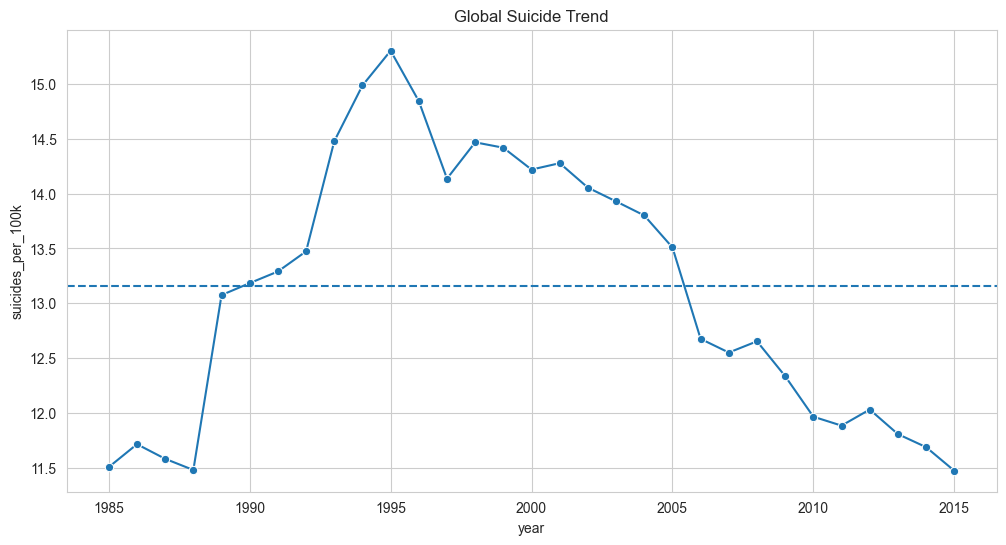

In [2]:
yearly = (
    df.groupby("year")
    .agg(
        population=("population","sum"),
        suicides=("suicides_no","sum")
    )
    .reset_index()
)

yearly["suicides_per_100k"] = (
    yearly["suicides"]
    /
    yearly["population"]
) * 100000

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly,
    x="year",
    y="suicides_per_100k",
    marker="o"
)

plt.axhline(
    global_average,
    linestyle="--"
)

plt.title("Global Suicide Trend")
plt.show()

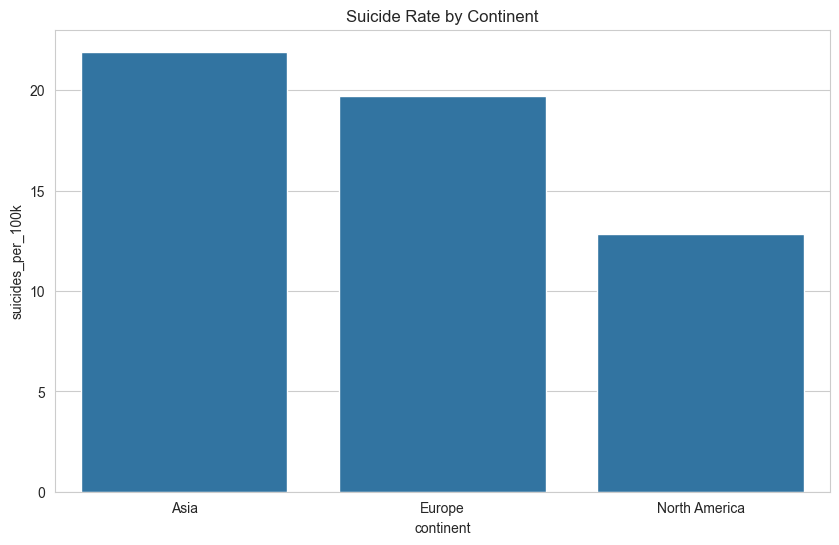

In [3]:
continent = (
    df.groupby("continent")
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

continent["suicides_per_100k"] = (
    continent["suicides"]
    /
    continent["population"]
) * 100000

plt.figure(figsize=(10,6))

sns.barplot(
    data=continent,
    x="continent",
    y="suicides_per_100k"
)

plt.title("Suicide Rate by Continent")
plt.show()

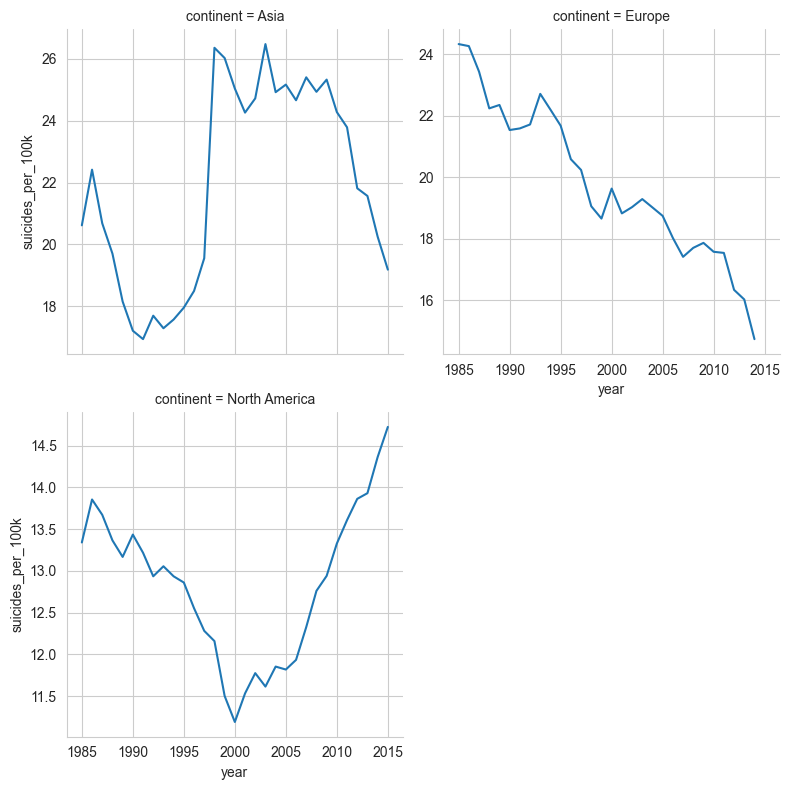

In [4]:
continent_time = (
    df.groupby(["year","continent"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

continent_time["suicides_per_100k"] = (
    continent_time["suicides"]
    /
    continent_time["population"]
) * 100000

g = sns.FacetGrid(
    continent_time,
    col="continent",
    col_wrap=2,
    sharey=False,
    height=4
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="suicides_per_100k"
)

plt.show()

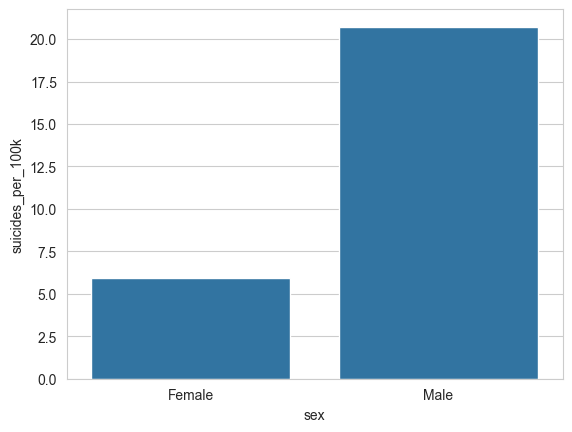

In [5]:
sex = (
    df.groupby("sex")
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

sex["suicides_per_100k"] = (
    sex["suicides"]
    /
    sex["population"]
) * 100000

sns.barplot(
    data=sex,
    x="sex",
    y="suicides_per_100k"
)

plt.show()

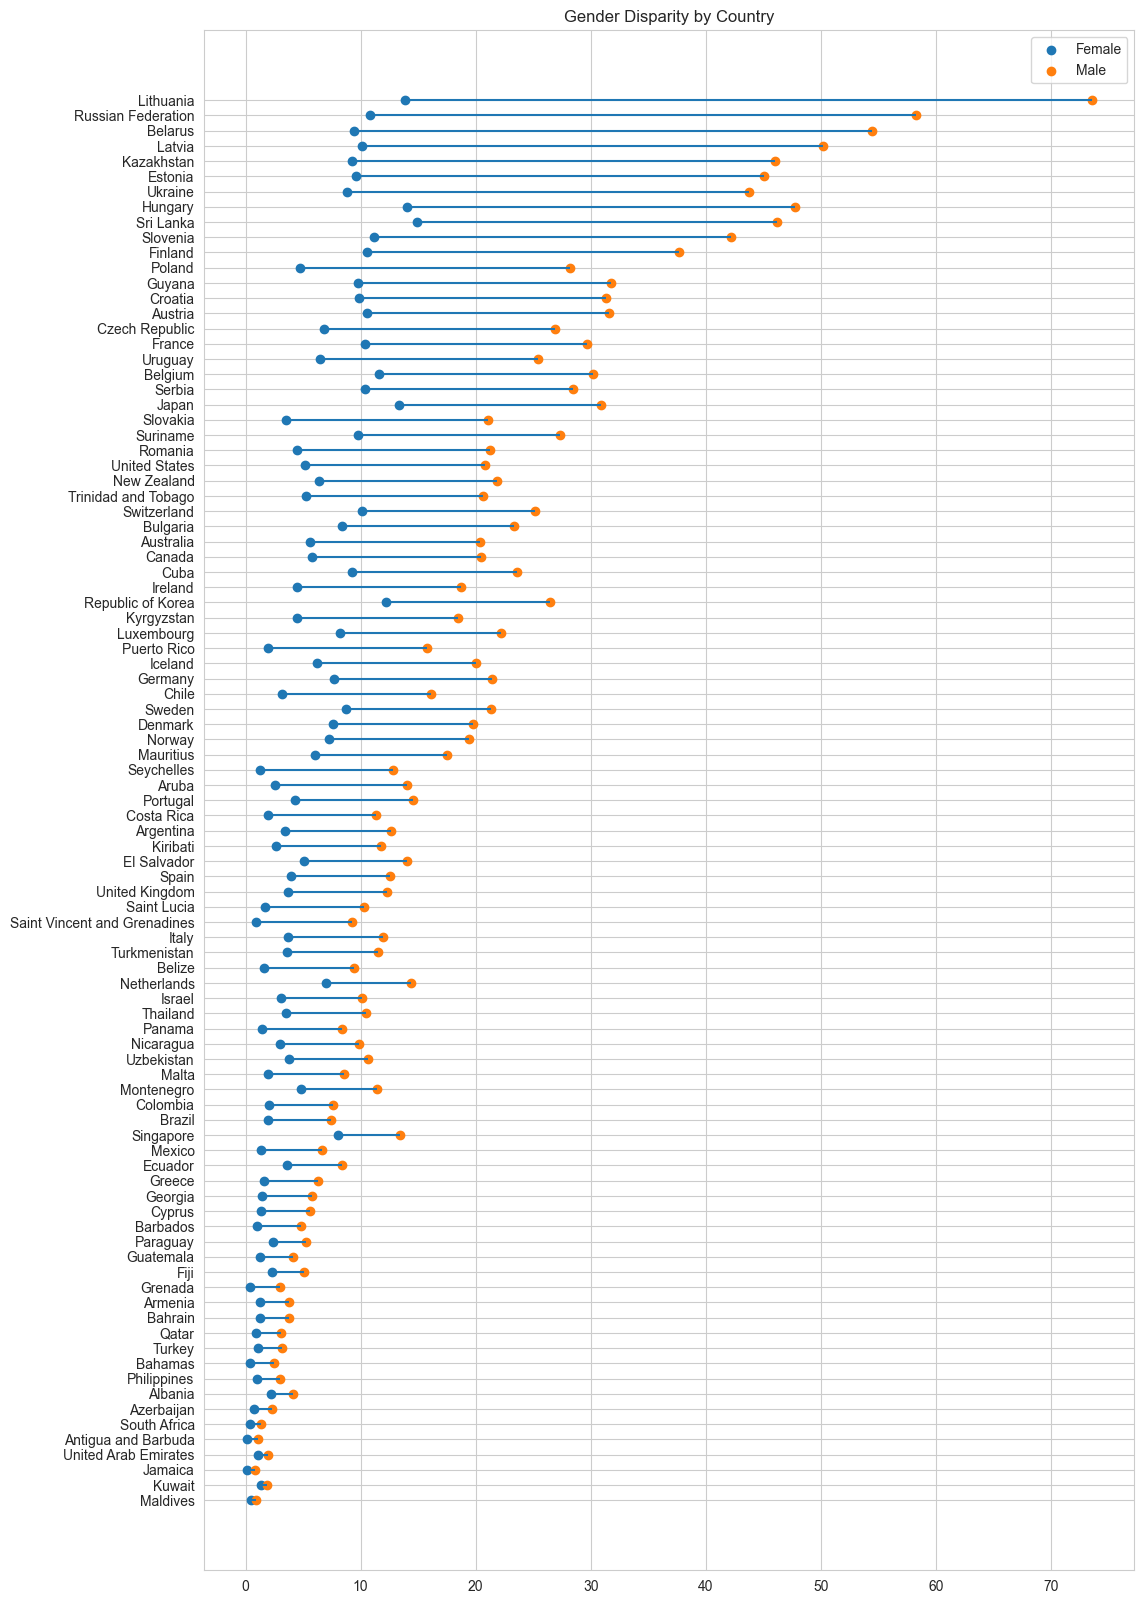

In [14]:
# =====================================
# GENDER DIFFERENCES BY COUNTRY
# =====================================

country_gender = (
    df.groupby(["country", "sex"])
    .agg(
        suicides=("suicides_no", "sum"),
        population=("population", "sum")
    )
    .reset_index()
)

country_gender["suicides_per_100k"] = (
    country_gender["suicides"]
    / country_gender["population"]
) * 100000

pivot_gender = (
    country_gender
    .pivot(
        index="country",
        columns="sex",
        values="suicides_per_100k"
    )
    .reset_index()
)

pivot_gender["difference"] = (
    pivot_gender["Male"]
    - pivot_gender["Female"]
)

pivot_gender = pivot_gender.sort_values(
    "difference"
)

plt.figure(figsize=(12,20))

plt.hlines(
    y=pivot_gender["country"],
    xmin=pivot_gender["Female"],
    xmax=pivot_gender["Male"]
)

plt.scatter(
    pivot_gender["Female"],
    pivot_gender["country"],
    label="Female"
)

plt.scatter(
    pivot_gender["Male"],
    pivot_gender["country"],
    label="Male"
)

plt.legend()
plt.title("Gender Disparity by Country")
plt.show()

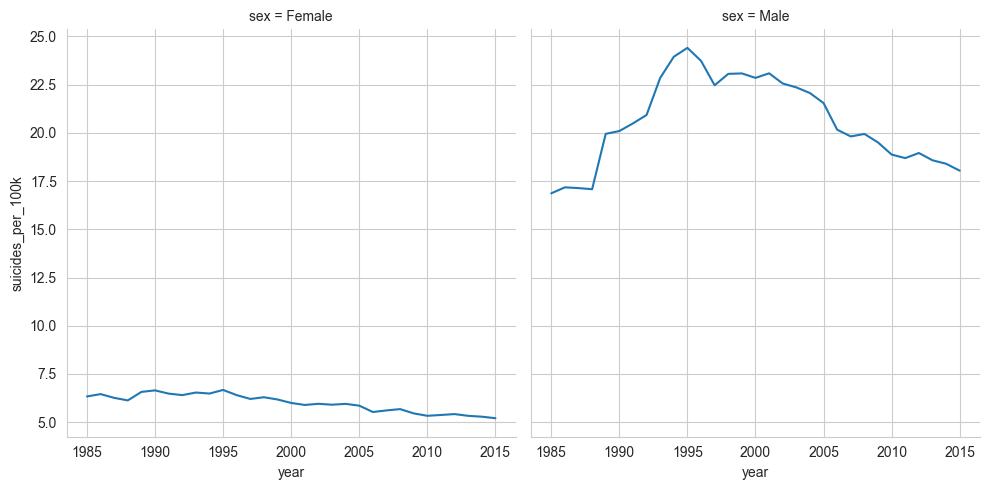

In [6]:
sex_time = (
    df.groupby(["year","sex"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

sex_time["suicides_per_100k"] = (
    sex_time["suicides"]
    /
    sex_time["population"]
) * 100000

sns.relplot(
    data=sex_time,
    x="year",
    y="suicides_per_100k",
    col="sex",
    kind="line"
)

plt.show()

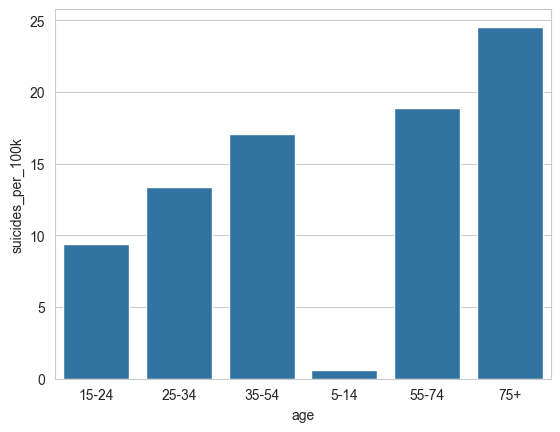

In [7]:
age = (
    df.groupby("age")
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

age["suicides_per_100k"] = (
    age["suicides"]
    /
    age["population"]
) * 100000

sns.barplot(
    data=age,
    x="age",
    y="suicides_per_100k"
)

plt.show()

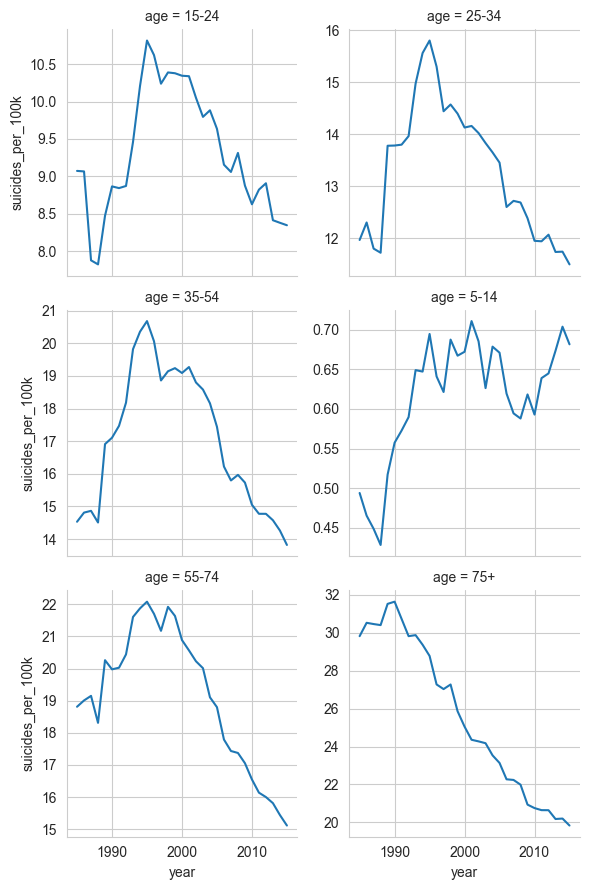

In [8]:
age_time = (
    df.groupby(["year","age"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

age_time["suicides_per_100k"] = (
    age_time["suicides"]
    /
    age_time["population"]
) * 100000

g = sns.FacetGrid(
    age_time,
    col="age",
    col_wrap=2,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="suicides_per_100k"
)

plt.show()

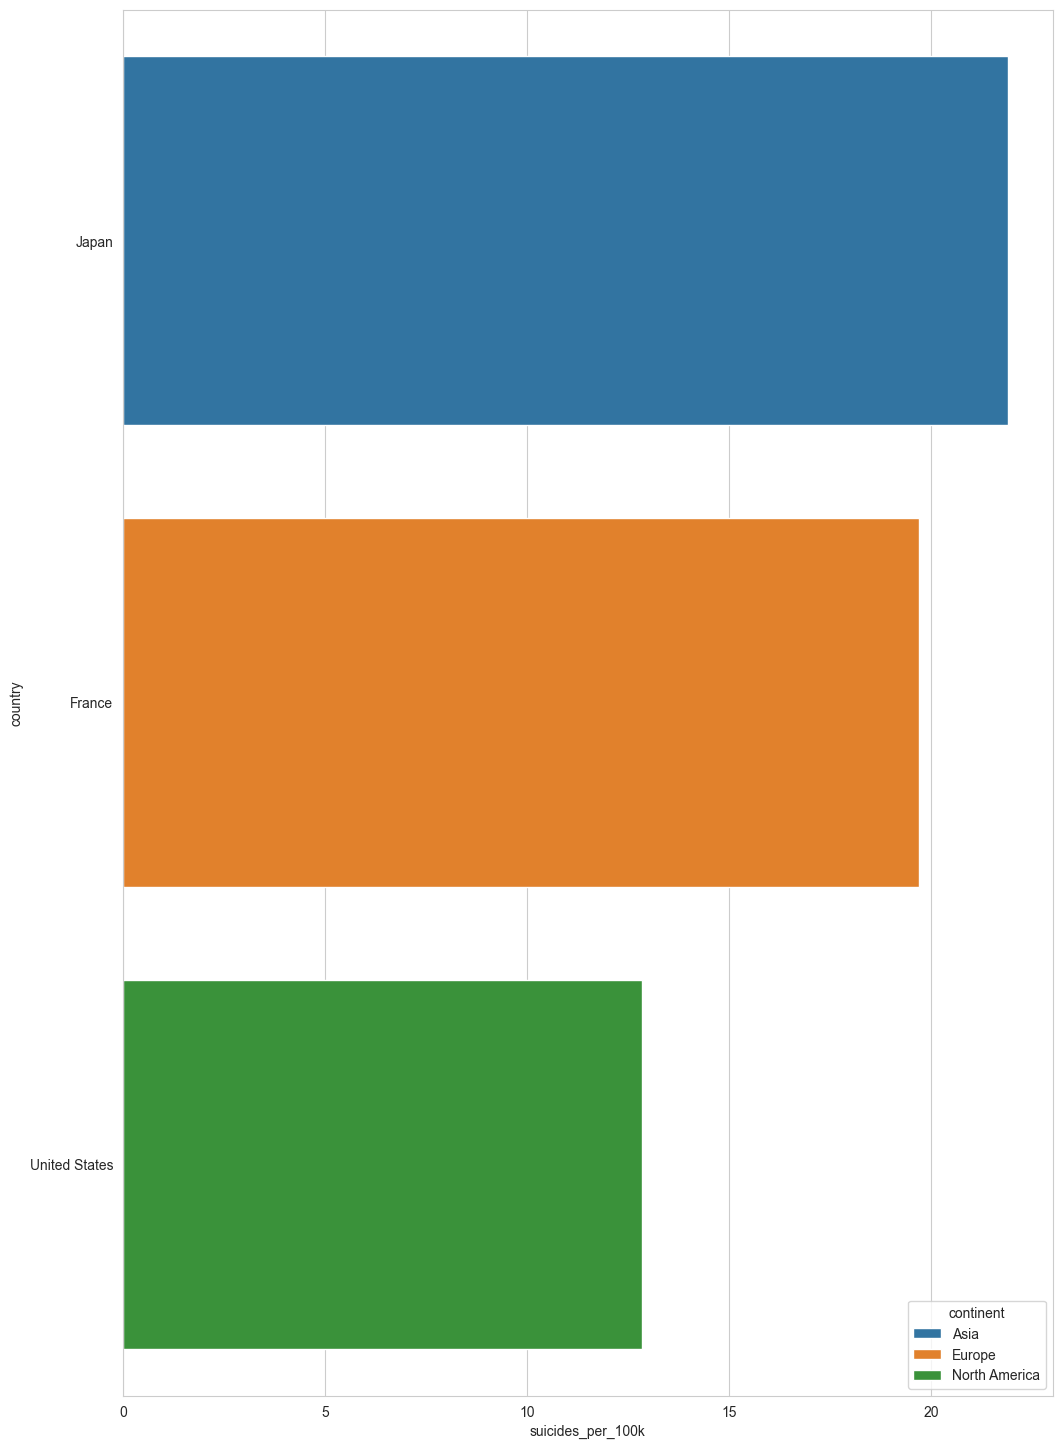

In [9]:
country = (
    df.groupby(["country","continent"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

country["suicides_per_100k"] = (
    country["suicides"]
    /
    country["population"]
) * 100000

country = (
    country
    .sort_values(
        "suicides_per_100k",
        ascending=False
    )
)

plt.figure(figsize=(12,18))

sns.barplot(
    data=country.head(30),
    y="country",
    x="suicides_per_100k",
    hue="continent"
)

plt.show()

In [ ]:
country_map = (
    df.groupby("country")
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

country_map["suicides_per_100k"] = (
    country_map["suicides"]
    /
    country_map["population"]
) * 100000

fig = px.choropleth(
    country_map,
    locations="country",
    locationmode="country names",
    color="suicides_per_100k",
    color_continuous_scale="Reds",
    title="Global Suicide Rates"
)

fig.show()

C:\Users\mkaan\AppData\Local\Temp\ipykernel_4668\3910050505.py:16: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


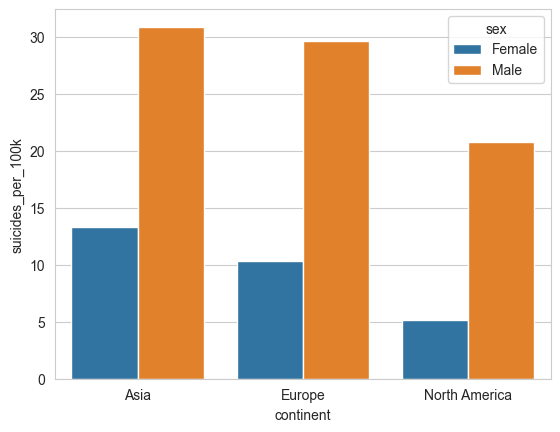

In [11]:
gender_continent = (
    df.groupby(["continent","sex"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

gender_continent["suicides_per_100k"] = (
    gender_continent["suicides"]
    /
    gender_continent["population"]
) * 100000

sns.barplot(
    data=gender_continent,
    x="continent",
    y="suicides_per_100k",
    hue="sex"
)

plt.show()

In [12]:
country_gender = (
    df.groupby(["country","sex"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

country_gender["suicides_per_100k"] = (
    country_gender["suicides"]
    /
    country_gender["population"]
) * 100000

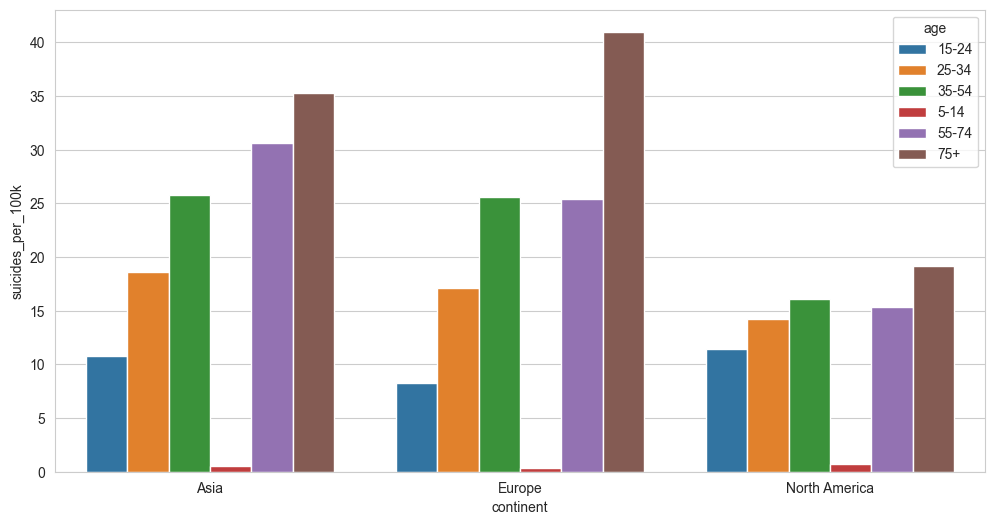

In [13]:
continent_age = (
    df.groupby(["continent","age"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

continent_age["suicides_per_100k"] = (
    continent_age["suicides"]
    /
    continent_age["population"]
) * 100000

plt.figure(figsize=(12,6))

sns.barplot(
    data=continent_age,
    x="continent",
    y="suicides_per_100k",
    hue="age"
)

plt.show()

# PART 3 — MODELING & STATISTICAL ANALYSIS